In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import emoji

from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
from transformers import AutoTokenizer
from textblob import TextBlob

### EDA on Sentiment Dataset

In [2]:
# Load Sentiment Data
df_sent_train = pd.read_csv("../data/raw/sentiment_train.csv")
df_sent_val = pd.read_csv("../data/raw/sentiment_validation.csv")
df_sent_test = pd.read_csv("../data/raw/sentiment_test.csv")

print("Sentiment train:", df_sent_train.shape)
print("Sentiment val:", df_sent_val.shape)
print("Sentiment test:", df_sent_test.shape)
print(df_sent_train.info())
print(df_sent_train.head())

Sentiment train: (45615, 2)
Sentiment val: (2000, 2)
Sentiment test: (12284, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45615 entries, 0 to 45614
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    45615 non-null  object
 1   label   45615 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 712.9+ KB
None
                                                text  label
0  "QT @user In the original draft of the 7th boo...      2
1  "Ben Smith / Smith (concussion) remains out of...      1
2  Sorry bout the stream last night I crashed out...      1
3  Chase Headley's RBI double in the 8th inning o...      1
4  @user Alciato: Bee will invest 150 million in ...      2


In [3]:
print("Missing values:")
print(df_sent_train.isnull().sum())

print("\nDuplicates:")
print(df_sent_train['text'].duplicated().sum())

Missing values:
text     0
label    0
dtype: int64

Duplicates:
29


/tmp/ipykernel_3099424/4129264565.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_sent_train, palette='viridis')


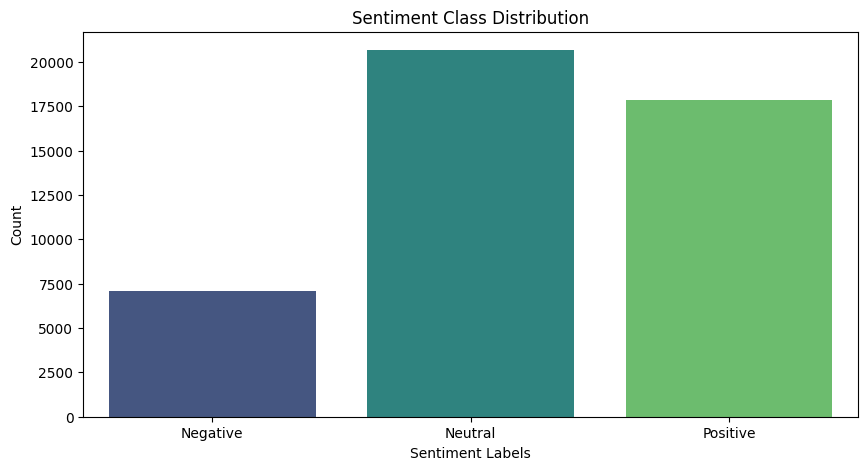

Percentage distribution of sentiment classes:
label
Neutral     0.453206
Positive    0.391297
Negative    0.155497
Name: proportion, dtype: float64


In [4]:
# Visualize Sentiment Class Distribution in the Training Set
plt.figure(figsize=(10, 5))
sns.countplot(x='label', data=df_sent_train, palette='viridis')
plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.xlabel('Sentiment Labels')
plt.ylabel('Count')
plt.title('Sentiment Class Distribution')
plt.show()
# Print percentage distribution of sentiment classes
print("Percentage distribution of sentiment classes:")
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
print(df_sent_train['label'].map(label_map).value_counts(normalize=True))


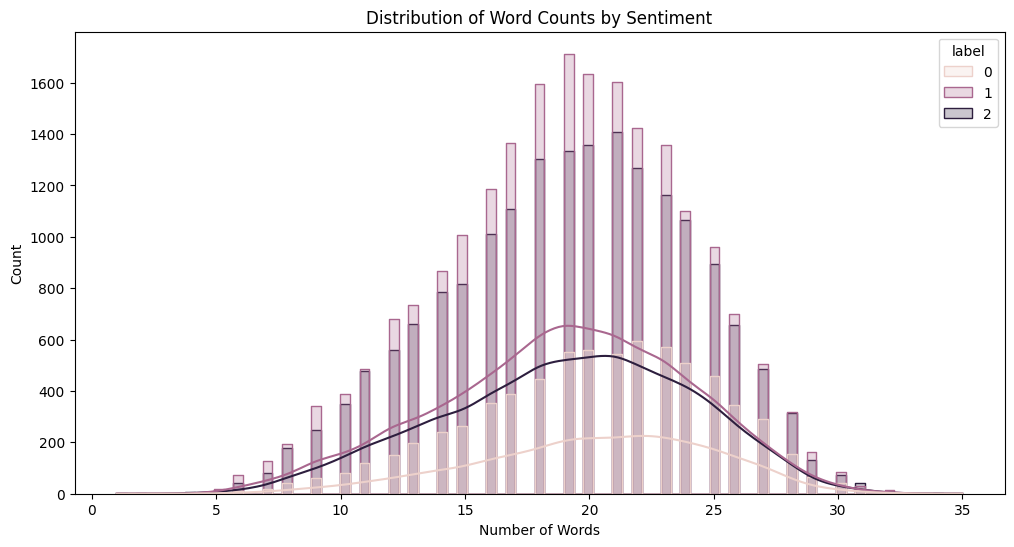

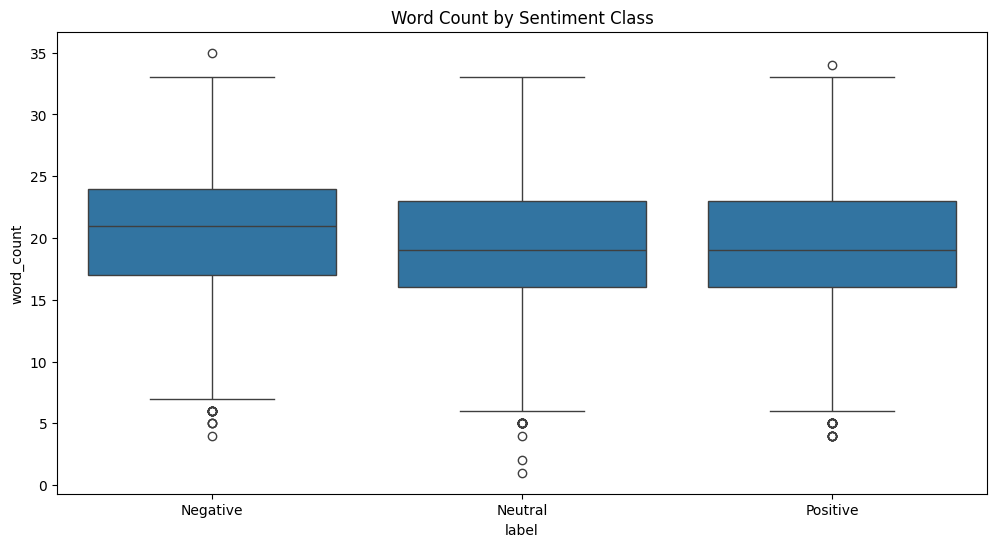

In [5]:
# Visualize Word Count Distribution by Sentiment Class
df_sent_train['char_length'] = df_sent_train['text'].apply(len)
df_sent_train['word_count'] = df_sent_train['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.histplot(data=df_sent_train, x='word_count', hue='label', kde=True, element="step")
plt.title('Distribution of Word Counts by Sentiment')
plt.xlabel('Number of Words')
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='label', y='word_count', data=df_sent_train)
plt.xticks([0, 1, 2], ['Negative', 'Neutral', 'Positive'])
plt.title("Word Count by Sentiment Class")
plt.show()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

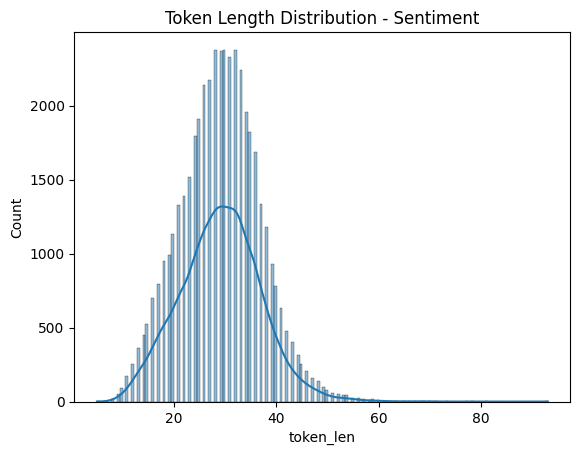

count    45615.000000
mean        29.118514
std          7.896788
min          5.000000
25%         24.000000
50%         29.000000
75%         34.000000
max         93.000000
Name: token_len, dtype: float64


In [6]:
tokenizer = AutoTokenizer.from_pretrained("roberta-base")

df_sent_train['token_len'] = df_sent_train['text'].apply(
    lambda x: len(tokenizer.encode(x, truncation=False))
)

sns.histplot(df_sent_train['token_len'], kde=True)
plt.title("Token Length Distribution - Sentiment")
plt.show()

print(df_sent_train['token_len'].describe())

In [9]:
def clean_for_eda(text):
    if not isinstance(text, str): return ""
    # A. Convert all 'uXXXX' hex codes to actual characters
    text = re.sub(r'u([0-9a-fA-F]{4})', lambda m: chr(int(m.group(1), 16)), text)
    # B. General Cleaning for EDA (Remove placeholders that bloat bigrams)
    text = text.lower()
    text = re.sub(r'@user|user|http\S+|http', '', text) # Remove @user, user, and urls
    # C. Standardize apostrophes (sometimes unicode conversion leaves varied types)
    text = re.sub(r"[\u2018\u2019\u201a\u201b]", "'", text)
    # D. Remove non-alphanumeric noise (keep spaces and apostrophes)
    text = re.sub(r"[^a-zA-Z'\s]", ' ', text)
    # E. Final squeeze (remove extra whitespace)
    return " ".join(text.split())

df_sent_train['clean_text'] = df_sent_train['text'].apply(clean_for_eda)

from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngram(corpus, n_top=10):
# We use 'english' stop words but also add common Twitter noise
    stop_words = list(CountVectorizer(stop_words='english').get_stop_words())
    stop_words.extend(['rt', 'amp', 'via']) 
    
    vec = CountVectorizer(ngram_range=(2, 2), stop_words=stop_words).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0) 
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    return sorted(words_freq, key=lambda x: x[1], reverse=True)[:n_top]

# Top Bigrams for Each Sentiment Class
labels = {0: "Negative", 1: "Neutral", 2: "Positive"}
for label_id, label_name in labels.items():
    subset = df_sent_train[df_sent_train['label'] == label_id]['clean_text']
    top_bi = get_top_ngram(subset)
    
    print(f"\n--- Top Bigrams for {label_name} ---")
    for phrase, freq in top_bi:
        print(f"{phrase:20} | {freq}")


--- Top Bigrams for Negative ---
boko haram           | 102
charlie hebdo        | 90
caitlyn jenner       | 76
big brother          | 69
kanye west           | 69
frank ocean          | 66
saudi arabia         | 63
tony blair           | 62
donald trump         | 62
amazon prime         | 56

--- Top Bigrams for Neutral ---
monday night         | 191
tomorrow night       | 186
real madrid          | 186
white sox            | 180
dustin johnson       | 170
seth rollins         | 169
red sox              | 169
john cena            | 165
saturday night       | 147
tom brady            | 146

--- Top Bigrams for Positive ---
tomorrow night       | 264
ant man              | 198
ice cream            | 196
monday night         | 184
foo fighters         | 173
friday night         | 164
hot dog              | 152
looking forward      | 148
cream day            | 148
national ice         | 146


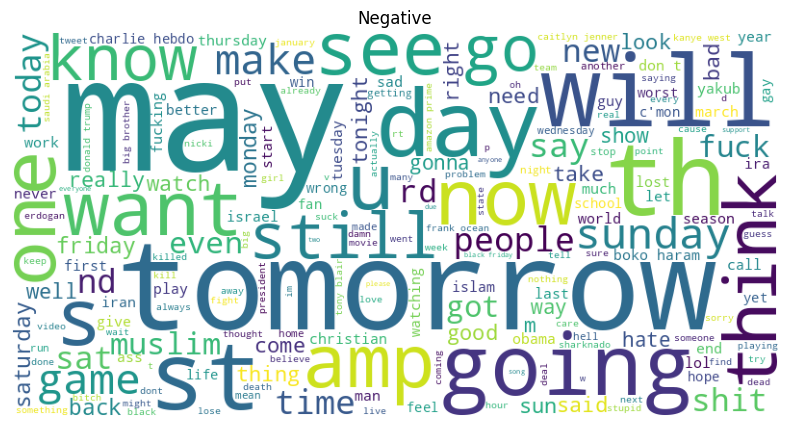

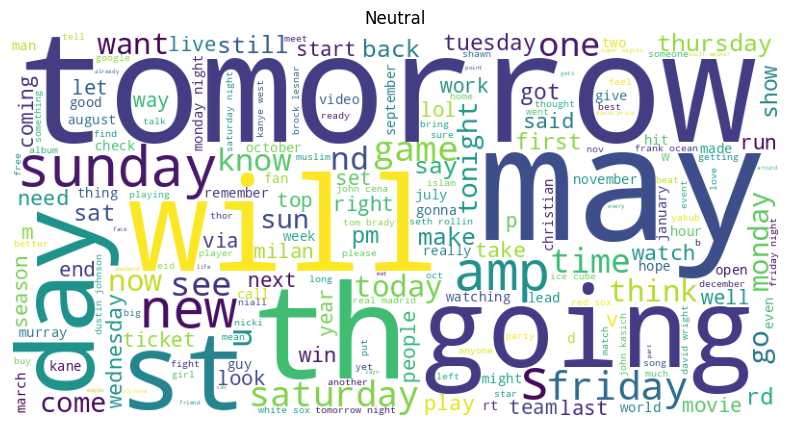

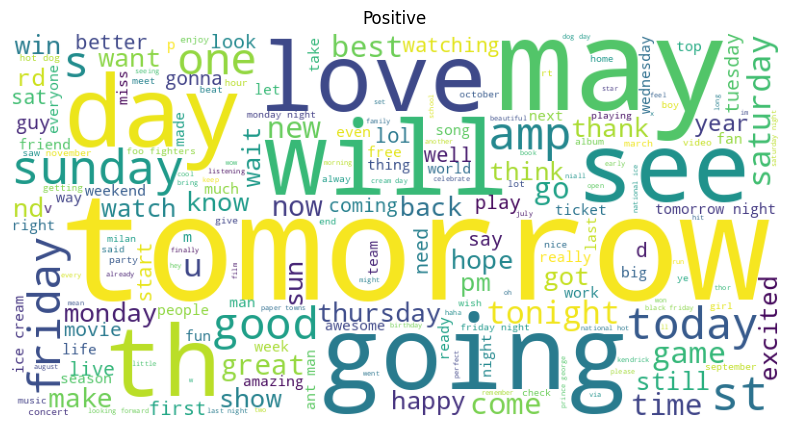

In [10]:
for label_id, label_name in labels.items():
    text = " ".join(df_sent_train[df_sent_train['label']==label_id]['clean_text'])

    wc = WordCloud(width=800,height=400,background_color='white').generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc)
    plt.axis('off')
    plt.title(label_name)
    plt.show()

In [31]:
# 1. Calculate lexicon sentiment for the Sentiment Dataset
df_sent_train['lexicon_polarity'] = df_sent_train['text'].apply(lambda x: TextBlob(x).sentiment.polarity)

# 2. Identify "Contradictory" Negative Tweets (Label is Negative, but words are Positive)
# These are the tweets that "confuse" the model
contradictory_neg = df_sent_train[(df_sent_train['label'] == 0) & (df_sent_train['lexicon_polarity'] > 0.2)]

print(f"Number of 'Contradictory' Negative tweets: {len(contradictory_neg)}")
print(f"Percentage of Negative class that is likely sarcastic/confusing: {len(contradictory_neg)/len(df_sent_train[df_sent_train['label']==0])*100:.2f}%")

# Show examples of these "confusing" tweets
print("\nExamples of Negative tweets with Positive words:")
print(contradictory_neg[['text', 'lexicon_polarity']].head(5))

Number of 'Contradictory' Negative tweets: 1108
Percentage of Negative class that is likely sarcastic/confusing: 15.62%

Examples of Negative tweets with Positive words:
                                                  text  lexicon_polarity
59   Amazon prime is literally a lie....I ordered a...          0.250000
60   Who the hell moshes at Matt and Kim?? Next tim...          0.250000
66   Mario Williams is catching hell! He will be Ex...          0.937500
158  "Oomf is gay. He may not know it yet, but I do...          0.608333
164  Yes it is. Bori practitioners have survived by...          0.433333


/tmp/ipykernel_3099424/2329175910.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='label', y='lexicon_polarity', data=df_sent_train, palette='viridis')


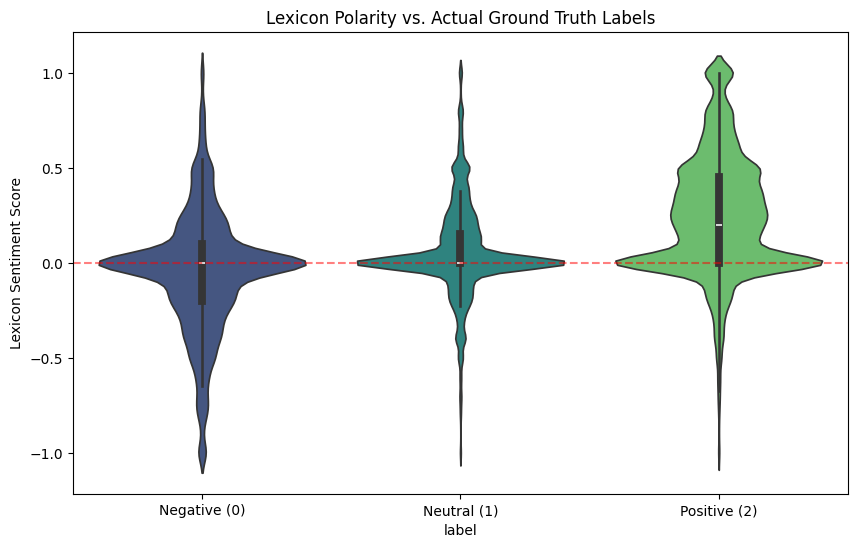

In [32]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='label', y='lexicon_polarity', data=df_sent_train, palette='viridis')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Lexicon Polarity vs. Actual Ground Truth Labels')
plt.xticks([0, 1, 2], ['Negative (0)', 'Neutral (1)', 'Positive (2)'])
plt.ylabel('Lexicon Sentiment Score')
plt.show()

In [36]:
# Look at Negative tweets that have the highest POSITIVE lexicon scores
confusing_negatives = df_sent_train[(df_sent_train['label'] == 0)].sort_values(by='lexicon_polarity', ascending=False)

print("Top 20 'Negative' tweets that use 'Positive' words (Likely Sarcastic):")
for i, row in confusing_negatives.head(20).iterrows():
    print(f"- Score: {row['lexicon_polarity']:.2f} | Text: {row['text']}")

Top 20 'Negative' tweets that use 'Positive' words (Likely Sarcastic):
- Score: 1.00 | Text: "The Great Wall of Sharknado, the 9th Wonder of the World. Oh, HELL NO! #Sharknado3"
- Score: 1.00 | Text: It official\u002c I will not be flying to Raleigh\u002c NC tomorrow. I\u2019m saddened. I pray my UPPC family has an awesome time in the LORD. #Praying
- Score: 1.00 | Text: The best way to find Malaysia Airlines Flight MH370 may be with Michelle Obama's arms.
- Score: 1.00 | Text: @user while the met may not be perfect why don't you piss off to somewhere like Mexico City if you don't like it!!?? #tottenham
- Score: 1.00 | Text: "All those who petitioned for stopping Yakub's hanging , may hang themselves ...This would be the best  ""Shraddhanjali"" to him"
- Score: 1.00 | Text: i haven\u2019t worn Makeup since Ash Wed. ;o <3 i don\u2019t like it anymore .
- Score: 1.00 | Text: Why is May Vaseline talking about Zayn like they're best friends?
- Score: 1.00 | Text: El Classico on a Sunday Ni

### EDA on Sarcasm Data

In [14]:
# Load Sarcasm
df_isarc_train = pd.read_csv("../data/raw/iSarcasm_Train.csv")
df_isarc_train = df_isarc_train[["tweet", "sarcastic"]].rename(
    columns={"tweet": "text", "sarcastic": "label"}
)
df_isarc_test = pd.read_csv("../data/raw/iSarcasm_Test.csv")
df_isarc_test = df_isarc_test[["text", "sarcastic"]].rename(
    columns={"sarcastic": "label"}
)
def load_semeval_taskB(filepath):
    """Load SemEval Task B and normalize labels to binary sarcasm."""
    data = []
    with open(filepath, "r", encoding="utf-8") as f:
        # Read lines and skip header if present
        lines = f.readlines()
        header = lines[0].lower()
        start_idx = 1 if "tweet" in header or "label" in header else 0

        for line in lines[start_idx:]:
            parts = line.strip().split("\t")
            if len(parts) >= 3:
                try:
                    # parts[1] is the Label, parts[2] is the Tweet text
                    raw_label = int(parts[1])
                    # Normalize: Labels 1 and 2 become 1 (Sarcastic/Ironic)
                    label = 1 if raw_label > 0 else 0
                    
                    text = parts[2].replace("||", " ") # Clean newline markers
                    
                    data.append({
                        "text": text,
                        "label": label
                    })
                except (ValueError, IndexError):
                    continue 
    return pd.DataFrame(data)

df_semeval_train = load_semeval_taskB("../data/raw/SemEval2018-T3-train-taskB.txt")
df_semeval_test = load_semeval_taskB("../data/raw/SemEval2018-T3_gold_test_taskB.txt")

# Combine all Sarcasm sources
df_sarc = pd.concat([df_isarc_train, df_isarc_test, df_semeval_train, df_semeval_test], ignore_index=True)

# Remove nulls and duplicates
df_sarc = df_sarc.dropna(subset=["text"]).drop_duplicates(subset=["text"])
df_sarc["text"] = df_sarc["text"].astype(str)

print("Sarcasm train:", df_sarc.shape)
print(df_sarc.info())
print(df_sarc.head())


Sarcasm train: (9468, 2)
<class 'pandas.core.frame.DataFrame'>
Index: 9468 entries, 0 to 9485
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    9468 non-null   object
 1   label   9468 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 221.9+ KB
None
                                                text  label
0  The only thing I got from college is a caffein...      1
1  I love it when professors draw a big question ...      1
2  Remember the hundred emails from companies whe...      1
3  Today my pop-pop told me I was not “forced” to...      1
4  @VolphanCarol @littlewhitty @mysticalmanatee I...      1


In [16]:
def preprocess_sarc(text):
    text = re.sub(r"@[^\s]+", "@user", text)
    text = re.sub(r"http\S+", "http", text)
    text = " ".join(text.split())
    text = emoji.demojize(text, delimiters=(" :", ": "))
    return text

df_sarc['text'] = df_sarc['text'].apply(preprocess_sarc)

/tmp/ipykernel_3099424/2267158689.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df_sarc, palette='viridis')


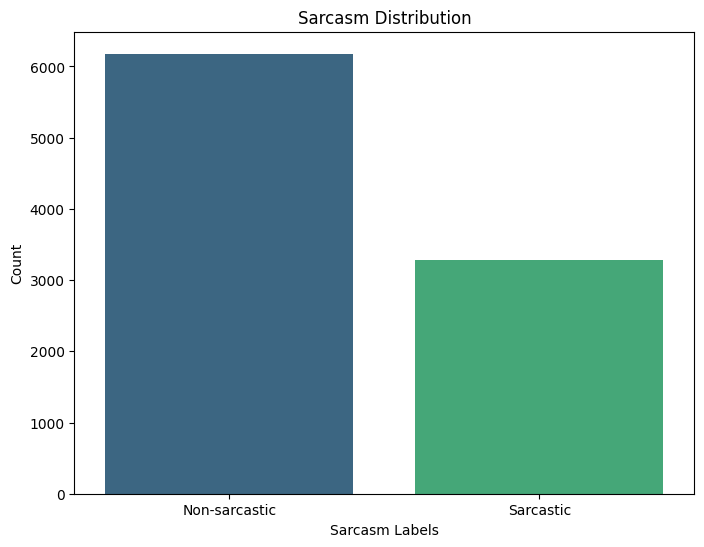

Percentage distribution of sarcasm classes:
label
Non-sarcastic    0.652619
Sarcastic        0.347381
Name: proportion, dtype: float64


In [22]:
# Visualize Sarcastic Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='label', data=df_sarc, palette='viridis')
plt.xticks([0, 1], ['Non-sarcastic', 'Sarcastic'])
plt.xlabel('Sarcasm Labels')
plt.ylabel('Count')
plt.title("Sarcasm Distribution")
plt.show()

# Print percentage distribution of sarcastic classes
print("Percentage distribution of sarcasm classes:")
label_map = {0: "Non-sarcastic", 1: "Sarcastic"}
print(df_sarc['label'].map(label_map).value_counts(normalize=True))

In [23]:
def clean_for_sarcasm_eda(text):
    text = text.lower()
    text = re.sub(r'@user|http', '', text)
    text = re.sub(r"[^a-zA-Z0-9'?!.\s]", ' ', text)
    return " ".join(text.split())

df_sarc['clean_text'] = df_sarc['text'].apply(clean_for_sarcasm_eda)

def get_top_bigrams_sarcasm(corpus, n_top=10):
    vec = CountVectorizer(
        ngram_range=(2,2),
        stop_words='english'
    ).fit(corpus)

    bag = vec.transform(corpus)
    sums = bag.sum(axis=0)

    words_freq = [
        (word, sums[0, idx])
        for word, idx in vec.vocabulary_.items()
    ]

    return sorted(words_freq, key=lambda x:x[1], reverse=True)[:n_top]

print("Normal:")
print(get_top_bigrams_sarcasm(
    df_sarc[df_sarc['label']==0]['clean_text']
))

print("Sarcastic:")
print(get_top_bigrams_sarcasm(
    df_sarc[df_sarc['label']==1]['clean_text']
))

Normal:
[('smiling face', np.int64(151)), ('face tears', np.int64(124)), ('tears joy', np.int64(124)), ('crying face', np.int64(93)), ('skin tone', np.int64(86)), ('loudly crying', np.int64(84)), ('light skin', np.int64(68)), ('red heart', np.int64(58)), ('face heart', np.int64(55)), ('face smiling', np.int64(49))]
Sarcastic:
[('smiling face', np.int64(78)), ('face tears', np.int64(72)), ('tears joy', np.int64(72)), ('unamused face', np.int64(41)), ('just love', np.int64(35)), ('skin tone', np.int64(26)), ('upside face', np.int64(25)), ('crying face', np.int64(25)), ('joy face', np.int64(24)), ('weary face', np.int64(24))]


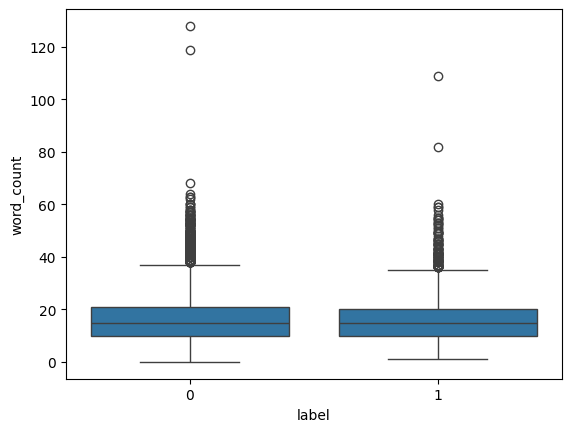

In [25]:
df_sarc['word_count'] = df_sarc['clean_text'].apply(lambda x: len(x.split()))

sns.boxplot(x='label', y='word_count', data=df_sarc)
plt.show()

In [26]:
markers = ['!', '?', '...']

for m in markers:
    df_sarc[m] = df_sarc['text'].str.count(re.escape(m))

df_sarc.groupby('label')[markers].mean()

,!,?,...
label,,,
0,0.224308,0.141609,0.082861
1,0.292794,0.155062,0.110976


In [27]:
def top_words(series, n=500):
    vec = CountVectorizer(stop_words='english')
    X = vec.fit_transform(series)
    freqs = np.asarray(X.sum(axis=0)).flatten()
    words = np.array(vec.get_feature_names_out())
    top = words[np.argsort(freqs)[::-1][:n]]
    return set(top)

sent_vocab = top_words(df_sent_train['clean_text'])
sarc_vocab = top_words(df_sarc['clean_text'])

print("Overlap:", len(sent_vocab & sarc_vocab))

Overlap: 266


/tmp/ipykernel_3099424/3577445180.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='punc_count', data=df_sarc_style, ax=ax[0], palette='magma')
/tmp/ipykernel_3099424/3577445180.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='label', y='caps_ratio', data=df_sarc_style, ax=ax[1], palette='magma')


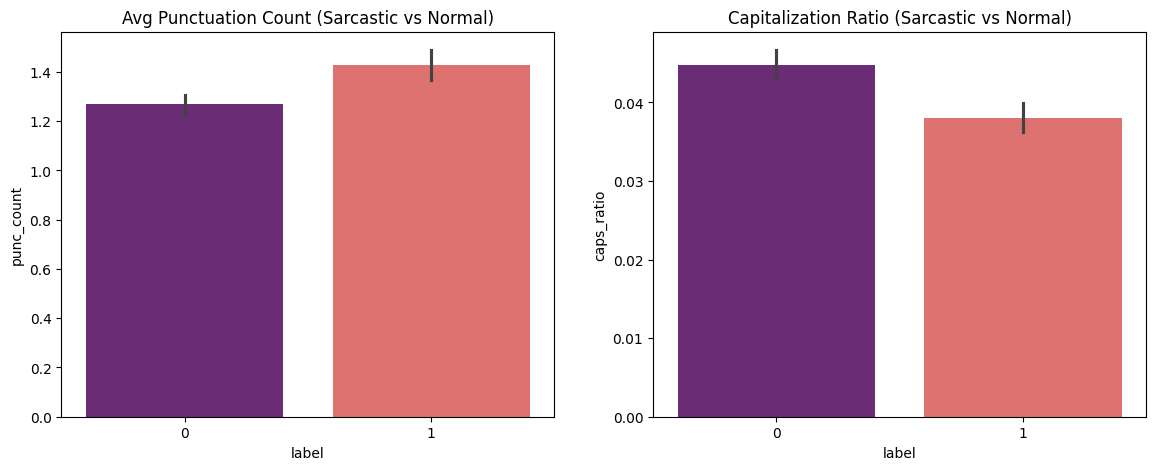

In [28]:
## 1. Intensity and Stylometric Analysis
def get_stylometrics(df):
    df = df.copy()
    # Punctuation density
    df['punc_count'] = df['text'].apply(lambda x: len(re.findall(r'[!?.]', x)))
    # Capitalization ratio (often used in sarcasm)
    df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()) / (len(x)+1))
    return df

df_sarc_style = get_stylometrics(df_sarc)

# Plotting the difference
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(x='label', y='punc_count', data=df_sarc_style, ax=ax[0], palette='magma')
ax[0].set_title('Avg Punctuation Count (Sarcastic vs Normal)')

sns.barplot(x='label', y='caps_ratio', data=df_sarc_style, ax=ax[1], palette='magma')
ax[1].set_title('Capitalization Ratio (Sarcastic vs Normal)')
plt.show()

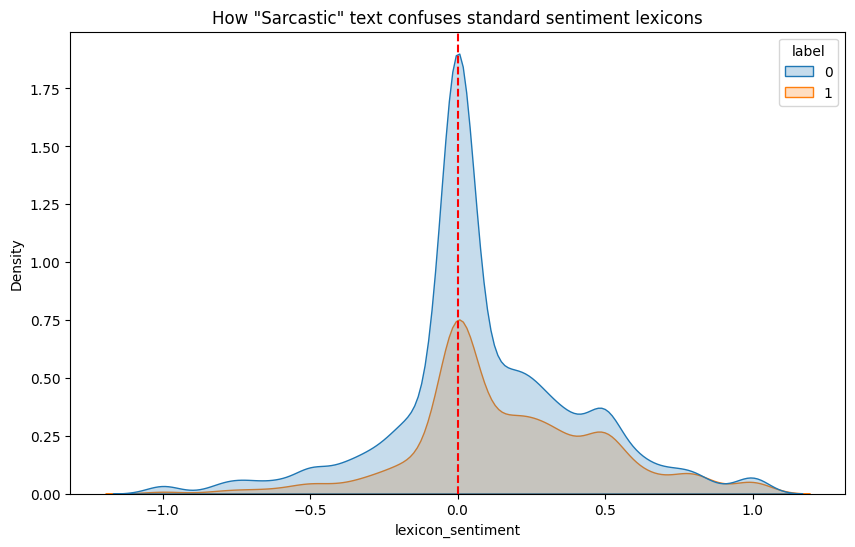

In [ ]:
# "Sentiment Conflict" Visualization
def get_sentiment_score(text):
    return TextBlob(text).sentiment.polarity

# Apply to Sarcasm dataset to see how a "naive" model sees it
df_sarc['lexicon_sentiment'] = df_sarc['text'].apply(get_sentiment_score)

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_sarc, x='lexicon_sentiment', hue='label', fill=True)
plt.title('How "Sarcastic" text confuses standard sentiment lexicons')
plt.axvline(0, color='red', linestyle='--')
plt.show()